# GRACE universal potentials in LAMMPS, via `pylammpsmpi`

This notebook drives the same `pair_style grace/fs` potential as [`01_lammps_grace_with_lammpsparser.ipynb`](01_lammps_grace_with_lammpsparser.ipynb), but through [`pylammpsmpi`](https://pylammpsmpi.readthedocs.io/en/latest/) instead of writing a LAMMPS input file.

`pylammpsmpi` controls a `mpi4py`-parallel LAMMPS instance from an ordinary (serial) Python process or notebook. Its `LammpsLibrary` interface exposes LAMMPS input-script commands as Python method/attribute calls (`lmp.pair_style(...)`, `lmp.run(...)`, ...) and thermodynamic keywords as properties (`lmp.pe`, `lmp.temp`, ...), which is convenient for anyone already familiar with LAMMPS input files who wants to drive a calculation interactively or step-by-step instead of through a static script.

We use `grace/fs` - the native, TensorFlow-free GRACE evaluator - because the `conda-forge` LAMMPS build does not link `libtensorflow` and therefore does not compile the TensorFlow-based `pair_style grace`.

## 1. Get a GRACE/FS foundation model

`grace/fs` reads a native YAML file exported from a model *checkpoint* with `grace_utils` (see the other notebook for why). Skip this cell if you already ran it there - the `~/.cache/grace` cache is shared.

In [1]:
import os

model_name = "GRACE-FS-OAM"
checkpoint_dir = os.path.expanduser(os.path.join("~/.cache/grace/checkpoints", model_name))
fs_model_path = os.path.join(checkpoint_dir, "FS_model.yaml")

!grace_models checkpoint {model_name}
!grace_utils -p {checkpoint_dir}/model.yaml -c {checkpoint_dir}/checkpoint export -sf -n {fs_model_path}

[tensorpotential] Info: Environment variable TF_USE_LEGACY_KERAS is automatically set to '1'.
[tensorpotential] Info: tf.experimental.numpy behavior enabled.
[tensorpotential] Info: TensorFloat-32 execution disabled.
Using cached GRACE checkpoint from /home/jovyan/.cache/grace/checkpoints/GRACE-FS-OAM
Model license: Academic Software License
Checkpoint for GRACE-FS-OAM downloaded successfully.
[tensorpotential] Info: Environment variable TF_USE_LEGACY_KERAS is automatically set to '1'.
[tensorpotential] Info: tf.experimental.numpy behavior enabled.
[tensorpotential] Info: TensorFloat-32 execution disabled.
2026/09/20 10:31:08 I - No param_dtype in model.yaml (old model) — using float64 for backward compatibility
2026/09/20 10:31:08 I - Converting model /home/jovyan/.cache/grace/checkpoints/GRACE-FS-OAM/model.yaml with checkpoint at /home/jovyan/.cache/grace/checkpoints/GRACE-FS-OAM/checkpoint to dict-like model
2026/09/20 10:31:08 I - Loading model from /home/jovyan/.cache/grace/checkp

## 2. Start a LAMMPS instance

`LammpsLibrary(cores=1)` launches an `mpi4py` LAMMPS process (via `openmpi`/`mpiexec`) in the background and gives us a handle to it.

In [2]:
from pylammpsmpi import LammpsLibrary

element = "Al"
lmp = LammpsLibrary(cores=1)

LAMMPS (22 Jul 2025 - Update 6)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread.
  using 1 OpenMP thread(s) per MPI task


## 3. Build an fcc aluminium cell and attach the GRACE/FS potential

Instead of loading a structure from a data file, we build it directly with LAMMPS' own `lattice`/`region`/`create_atoms` commands - the classic LAMMPS-input-script way of setting up a calculation.

Note: `create_atoms` is also the name of a lower-level array-based method on `LammpsLibrary` (mirroring the LAMMPS C library API), so to send it as a plain input-script command we go through `lmp.command(...)` explicitly; every other command below is available directly as an attribute.

In [3]:
lmp.units("metal")
lmp.atom_style("atomic")
lmp.boundary("p", "p", "p")

a0 = 4.05  # Angstrom, approximate fcc Al lattice constant
lmp.lattice("fcc", a0)
lmp.region("box", "block", 0, 3, 0, 3, 0, 3)
lmp.create_box(1, "box")
lmp.command("create_atoms 1 box")
lmp.mass(1, 26.9815386)

lmp.pair_style("grace/fs")
lmp.pair_coeff("*", "*", fs_model_path, element)

print("Number of atoms:", lmp.get_natoms())

Lattice spacing in x,y,z = 4.05 4.05 4.05
Created orthogonal box = (0 0 0) to (12.15 12.15 12.15)
  1 by 1 by 1 MPI processor grid
Created 108 atoms
  using lattice units in orthogonal box = (0 0 0) to (12.15 12.15 12.15)
  create_atoms CPU = 0.001 seconds
[GRACE/FS]
[GRACE-FS] Version: 2025.12.4p1
[GRACE-FS] Product evaluator is used
[GRACE-FS] Loading /home/jovyan/.cache/grace/checkpoints/GRACE-FS-OAM/FS_model.yaml
[GRACE-FS] Supporting 89 elements: Ac Ag Al Ar As Au B Ba Be Bi Br C Ca Cd Ce Cl Co Cr Cs Cu Dy Er Eu F Fe Ga Gd Ge H He Hf Hg Ho I In Ir K Kr La Li Lu Mg Mn Mo N Na Nb Nd Ne Ni Np O Os P Pa Pb Pd Pm Pr Pt Pu Rb Re Rh Ru S Sb Sc Se Si Sm Sn Sr Ta Tb Tc Te Th Ti Tl Tm U V W Xe Y Yb Zn Zr 
[GRACE-FS] Number of functions per element: 205 
[GRACE-FS] Mapping LAMMPS atom type #1(Al) -> ACE species type #2
Number of atoms: 108


## 4. Static energy evaluation

Thermodynamic keywords (`pe`, `temp`, `press`, ...) are available as plain attributes and are computed on demand, independent of what `thermo_style` prints.

In [4]:
lmp.run(0)
print("Potential energy (eV):", lmp.pe)

For more information see https://docs.lammps.org/err0028 (src/verlet.cpp:60)
Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 8
  ghost atom cutoff = 8
  binsize = 4, bins = 4 4 4
  1 neighbor lists, perpetual/occasional/extra = 1 0 0
  (1) pair grace/fs, perpetual
      attributes: full, newton on
      pair build: full/bin/atomonly
      stencil: full/bin/3d
      bin: standard
Setting up Verlet run ...
  Unit style    : metal
  Current step  : 0
  Time step     : 0.001
Per MPI rank memory allocation (min/avg/max) = 3.098 | 3.098 | 3.098 Mbytes
   Step          Temp          E_pair         E_mol          TotEng         Press     
         0   0             -402.31514      0             -402.31514      13794.662    
Loop time of 2.039e-06 on 1 procs for 0 steps with 108 atoms

98.1% CPU use with 1 MPI tasks x 1 OpenMP threads

MPI task timing breakdown:
Section |  min time  |  a

## 5. Short NVT molecular-dynamics run

We step the trajectory in chunks of 25 MD steps and read back the instantaneous temperature and total energy after each chunk - the kind of interactive, step-by-step control that the library interface (as opposed to a static input file) makes easy.

In [5]:
lmp.velocity("all", "create", 500.0, 12345)
lmp.fix("nvt_fix", "all", "nvt", "temp", 500.0, 500.0, 0.1)
lmp.timestep(0.001)

n_chunks = 20
steps_per_chunk = 25

steps, temperatures, energies = [], [], []
for i in range(n_chunks):
    lmp.run(steps_per_chunk)
    steps.append((i + 1) * steps_per_chunk)
    temperatures.append(lmp.temp)
    energies.append(lmp.etotal)

lmp.unfix("nvt_fix")

Setting up Verlet run ...
  Unit style    : metal
  Current step  : 0
  Time step     : 0.001
Per MPI rank memory allocation (min/avg/max) = 3.098 | 3.098 | 3.098 Mbytes
   Step          Temp          E_pair         E_mol          TotEng         Press     
         0   500           -402.31514      0             -395.39972      17912.874    
        25   230.0294      -398.5526       0             -395.3711       32712.244    
Loop time of 0.527255 on 1 procs for 25 steps with 108 atoms

Performance: 4.097 ns/day, 5.858 hours/ns, 47.415 timesteps/s, 5.121 katom-step/s
90.5% CPU use with 1 MPI tasks x 1 OpenMP threads

MPI task timing breakdown:
Section |  min time  |  avg time  |  max time  |%varavg| %total
---------------------------------------------------------------
Pair    | 0.5269     | 0.5269     | 0.5269     |   0.0 | 99.93
Neigh   | 0          | 0          | 0          |   0.0 |  0.00
Comm    | 0.00011629 | 0.00011629 | 0.00011629 |   0.0 |  0.02
Output  | 4.5768e-05 | 4.5768e

1

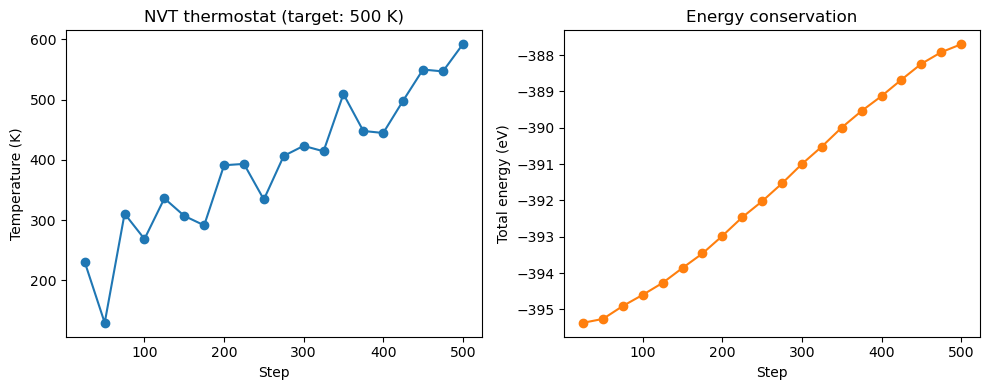

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(steps, temperatures, marker="o")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Temperature (K)")
axes[0].set_title("NVT thermostat (target: 500 K)")

axes[1].plot(steps, energies, marker="o", color="tab:orange")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Total energy (eV)")
axes[1].set_title("Energy conservation")

fig.tight_layout()
plt.show()

## 6. Shut down the LAMMPS instance

In [7]:
lmp.close()

[grace/fs] 56268 atoms, 521 calls, 108.0 atoms/step, 185.1 us/atom | Data: 0.3%, Model: 99.6%
Total wall time: 0:00:13
